# Model 3 - XGBoost
**Owner:** _(your name)_  |  **Branch:** `model/xgboost`  |  **Stage 6 + 7** - model development, comparison and optimisation

Gradient-boosted trees: each new tree corrects the errors of the previous ones. Usually the strongest model on tabular data, with the most hyper-parameters to tune.

> **How to run:** first set `DATA_FRAC = 0.1` to check that everything works (a few minutes), then set it to `1.0` and *Run All* for the real results.
> Everything here uses the shared code in `src/` - same split, same 5 folds, same metrics as the other members.

## 1. Setup and data

In [1]:
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
from common import *
from xgboost import XGBClassifier

NAME = "XGBoost"

# ---- run configuration ---------------------------------------------------------------------------
DATA_FRAC        = 1.0    # share of TRAINING patients used in this notebook (0.1 = quick check run)
EXP_FRAC         = 0.3    # share of patients used for the small experiments in section 4
TUNE_SAMPLE_FRAC = 0.3    # share of patients used DURING the search (the best model is refitted on ALL data)
N_ITER           = 15     # candidates tried by random / halving search
SEARCH_METHOD    = "random"   # "random" | "grid" | "halving"
# --------------------------------------------------------------------------------------------------
reset_log(NAME)

In [13]:
X_train, X_test, y_train, y_test, g_train, cv, class_names = load_and_split()
X_train, y_train, g_train = patient_subsample(X_train, y_train, g_train, DATA_FRAC)
X_exp, y_exp, g_exp = patient_subsample(X_train, y_train, g_train, EXP_FRAC)
print("train", X_train.shape, "| test", X_test.shape, "| classes", class_names)
pd.Series(y_train).map(dict(enumerate(class_names))).value_counts(normalize=True).round(3)

train (79541, 50) | test (19802, 50) | classes ['<30', '>30', 'NO']


NO     0.528
>30    0.357
<30    0.114
Name: proportion, dtype: float64

## 3. Baseline model and validation strategy
- **Validation:** 5-fold `StratifiedGroupKFold` on the training set, grouped by `patient_nbr` (a patient never appears in both the training and validation part of a fold) and stratified (the rare `<30` class, about 11%, appears in every fold). The folds are fixed (`random_state=42`) and identical for every model.
- **Preprocessing inside the pipeline:** imputation, scaling and one-hot encoding are refitted on the training part of each fold, so nothing leaks from the validation part.
- **Imbalance:** handled with class weights, not by resampling (SMOTE works poorly on ~2,400 sparse one-hot columns).
- **Main metric: macro-F1** (every class counts equally). Accuracy is misleading here because always predicting `NO` already scores about 55%. We also track macro-recall, ROC-AUC (one-vs-rest) and PR-AUC / recall for the `<30` class.
- The **test set is not touched** until section 6.

In [14]:
def make_pipe(**kw):
    params = dict(n_estimators=300, learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree=0.8,
                  tree_method="hist", eval_metric="mlogloss", n_jobs=-1, random_state=RANDOM_STATE)
    params.update(kw)
    return Pipeline([("pre", make_preprocessor(scale=False)),
                     ("m", BalancedXGB(**params))])


pipe = make_pipe()
baseline = cv_evaluate(pipe, X_train, y_train, g_train, cv)
pd.Series({k: round(v, 4) for k, v in baseline.items() if not isinstance(v, list)})

cv_macro_f1           0.4515
cv_weighted_f1        0.5272
cv_macro_recall       0.4697
cv_macro_precision    0.4529
cv_accuracy           0.5137
cv_roc_auc_ovr        0.6688
cv_pr_auc_lt30        0.2230
cv_recall_lt30        0.3840
cv_precision_lt30     0.2089
cv_f1_lt30            0.2706
cv_macro_f1_std       0.0081
cv_pr_auc_lt30_std    0.0113
train_macro_f1        0.5725
fit_time_s            3.6242
dtype: float64

## 4. Experiments - understanding why the model behaves the way it does
Each experiment is cross-validated with the same folds on a patient sample (`EXP_FRAC`) and is saved automatically to `outputs/results/<model>_experiments.csv` (this is your experiment record for the report).

### Experiment 1
**Learning rate vs number of trees** - a small learning rate needs more trees but usually generalises better.

In [15]:
for lr_, n in [(0.3, 100), (0.1, 300), (0.05, 600)]:
    run_experiment(NAME, "Learning rate x trees", f"lr={lr_}, trees={n}",
                   make_pipe(learning_rate=lr_, n_estimators=n, max_depth=4), X_exp, y_exp, g_exp, cv)
show_experiments(NAME, "Learning rate x trees")

[Learning rate x trees] lr=0.3, trees=100: macro-F1=0.4374 (train 0.5658)
[Learning rate x trees] lr=0.1, trees=300: macro-F1=0.4386 (train 0.5720)
[Learning rate x trees] lr=0.05, trees=600: macro-F1=0.4412 (train 0.5759)


,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,Learning rate x trees,"lr=0.3, trees=100",0.4374,0.5658,0.4528,0.6523,0.1899,0.7482
1,Learning rate x trees,"lr=0.1, trees=300",0.4386,0.5720,0.4533,0.6570,0.1938,1.6908
2,Learning rate x trees,"lr=0.05, trees=600",0.4412,0.5759,0.4563,0.6584,0.1964,3.5822


### Experiment 2
**Tree depth** - controls how many feature interactions each tree can model.

[max_depth] max_depth=3: macro-F1=0.4343 (train 0.4931)
[max_depth] max_depth=4: macro-F1=0.4369 (train 0.5311)
[max_depth] max_depth=6: macro-F1=0.4447 (train 0.6240)
[max_depth] max_depth=8: macro-F1=0.4421 (train 0.7283)


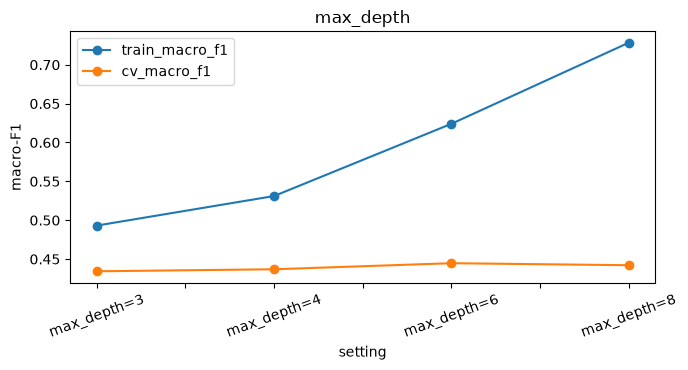

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,max_depth,max_depth=3,0.4343,0.4931,0.4559,0.6599,0.2005,2.7113
1,max_depth,max_depth=4,0.4369,0.5311,0.4550,0.6605,0.1996,2.5395
2,max_depth,max_depth=6,0.4447,0.6240,0.4567,0.6581,0.1947,3.4170
3,max_depth,max_depth=8,0.4421,0.7283,0.4473,0.6544,0.1838,4.8924


In [16]:
sweep(NAME, "max_depth", [3, 4, 6, 8], lambda v: make_pipe(max_depth=v, n_estimators=150), X_exp, y_exp, g_exp, cv)

### Experiment 3
**Feature engineering: do the 4 engineered features help?** (`total_previous_visits`, `has_previous_inpatient_visit`, `total_procedures`, `age_midpoint`)

In [17]:
ENGINEERED = ["total_previous_visits", "has_previous_inpatient_visit", "total_procedures", "age_midpoint"]
run_experiment(NAME, "Engineered features", "with", make_pipe(max_depth=4, n_estimators=150), X_exp, y_exp, g_exp, cv)
run_experiment(NAME, "Engineered features", "without", make_pipe(max_depth=4, n_estimators=150),
               X_exp.drop(columns=ENGINEERED), y_exp, g_exp, cv)
show_experiments(NAME, "Engineered features")

[Engineered features] with: macro-F1=0.4369 (train 0.5311)
[Engineered features] without: macro-F1=0.4374 (train 0.5292)


,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,Engineered features,with,0.4369,0.5311,0.4550,0.6605,0.1996,2.5455
1,Engineered features,without,0.4374,0.5292,0.4561,0.6591,0.1977,2.7037


### Experiment 4
**Imbalance handling** - balanced sample weights vs no weights. Compare macro-F1 with accuracy and `<30` recall (see the log file).

In [18]:
plain = Pipeline([("pre", make_preprocessor(scale=False)),
                  ("m", XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                                      tree_method="hist", eval_metric="mlogloss", n_jobs=-1, random_state=RANDOM_STATE))])
run_experiment(NAME, "Imbalance", "balanced weights", make_pipe(max_depth=4, n_estimators=150), X_exp, y_exp, g_exp, cv)
run_experiment(NAME, "Imbalance", "no weights", plain, X_exp, y_exp, g_exp, cv)
show_experiments(NAME, "Imbalance")

[Imbalance] balanced weights: macro-F1=0.4369 (train 0.5311)
[Imbalance] no weights: macro-F1=0.3950 (train 0.4479)


,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,Imbalance,balanced weights,0.4369,0.5311,0.4550,0.6605,0.1996,2.5553
1,Imbalance,no weights,0.3950,0.4479,0.4159,0.6687,0.2043,2.4777


## 5. Hyper-parameter tuning (Stage 7)
**Search strategy:** **Random search** (`RandomizedSearchCV`). Six hyper-parameters interact (learning rate x trees x depth x sampling), so a grid would explode; random search covers the space efficiently. If it is too slow, use `SEARCH_METHOD = "halving"`.

Scoring is **macro-F1** with the same grouped folds. To keep the search fast, it runs on `TUNE_SAMPLE_FRAC` of the patients and the best configuration is then **refitted on all training data**. The tuned model is re-evaluated with the full 5-fold CV so that baseline and tuned scores are directly comparable.

In [19]:
space = {"m__max_depth": [3, 4, 6, 8],
         "m__learning_rate": [0.03, 0.05, 0.1, 0.2],
         "m__n_estimators": [200, 400, 600],
         "m__subsample": [0.7, 0.85, 1.0],
         "m__colsample_bytree": [0.6, 0.8, 1.0],
         "m__min_child_weight": [1, 3, 5]}


tune_res = tune(pipe, space, X_train, y_train, g_train, cv,
                method=SEARCH_METHOD, n_iter=N_ITER, sample_frac=TUNE_SAMPLE_FRAC)
print("Best parameters:", tune_res.best_params_)
print(f"Search took {tune_res.search_time_s/60:.1f} min")
top_configs(tune_res)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters: {'m__subsample': 0.85, 'm__n_estimators': 600, 'm__min_child_weight': 1, 'm__max_depth': 8, 'm__learning_rate': 0.05, 'm__colsample_bytree': 0.8}
Search took 7.5 min


,param_m__subsample,param_m__n_estimators,param_m__min_child_weight,param_m__max_depth,param_m__learning_rate,param_m__colsample_bytree,mean_test_score,std_test_score
7,0.85,600,1,8,0.05,0.8,0.4510,0.0040
14,0.85,200,5,8,0.03,1.0,0.4482,0.0052
3,0.70,400,1,6,0.05,1.0,0.4469,0.0049
9,0.85,400,5,6,0.03,0.6,0.4453,0.0050
12,0.85,400,5,6,0.10,0.8,0.4448,0.0051


In [20]:
tuned = cv_evaluate(tune_res.best_estimator_, X_train, y_train, g_train, cv)   # full 5-fold CV, comparable with baseline
compare_table(baseline, tuned)

,baseline,tuned,change
CV macro-F1 (main metric),0.4515,0.4556,0.0042
CV macro-recall,0.4697,0.4675,-0.0022
CV accuracy,0.5137,0.5240,0.0103
"CV ROC-AUC (OvR, macro)",0.6688,0.6692,0.0004
CV PR-AUC for <30,0.2230,0.2207,-0.0023
CV recall for <30,0.3840,0.3401,-0.0440
Train macro-F1 (over-fit check),0.5725,0.6616,0.0891
Fit time per fold (s),3.6242,11.8421,8.2179


## 6. Final evaluation on the untouched test set (reported once)
The final model of the project is chosen later, in `compare_models.ipynb`, by **CV score - not by test score**.

              precision    recall  f1-score   support

         <30      0.217     0.358     0.271      2216
         >30      0.488     0.448     0.467      7090
          NO      0.673     0.618     0.644     10496

    accuracy                          0.528     19802
   macro avg      0.459     0.475     0.461     19802
weighted avg      0.556     0.528     0.539     19802



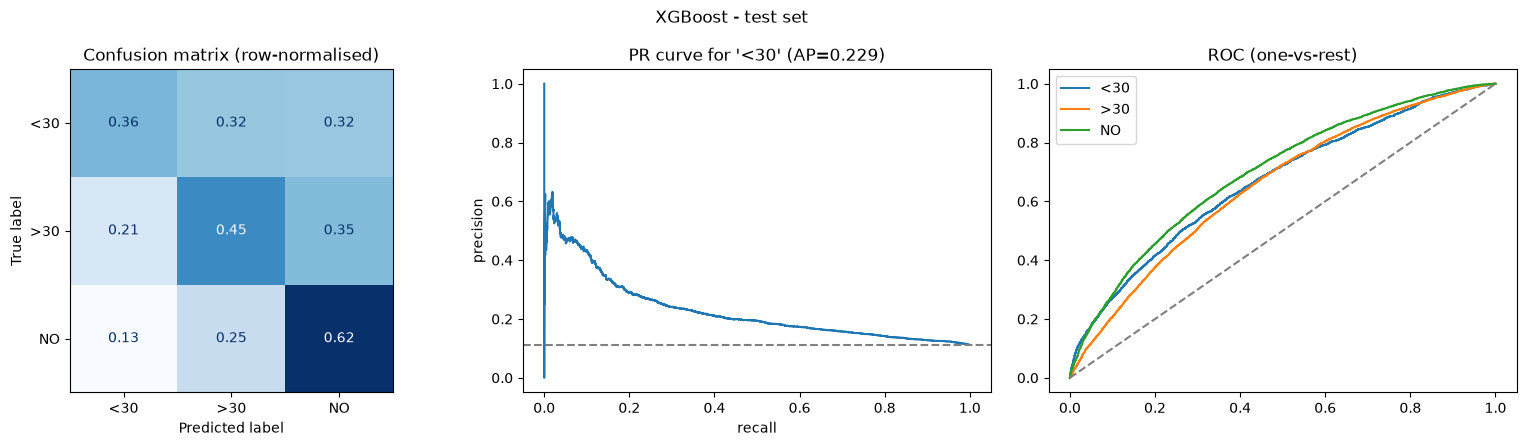

Saved outputs/results/xgboost.json and outputs/models/xgboost.joblib


In [21]:
result = finalize(NAME, baseline, tuned, tune_res, X_test, y_test, class_names)

## 7. Interpretation

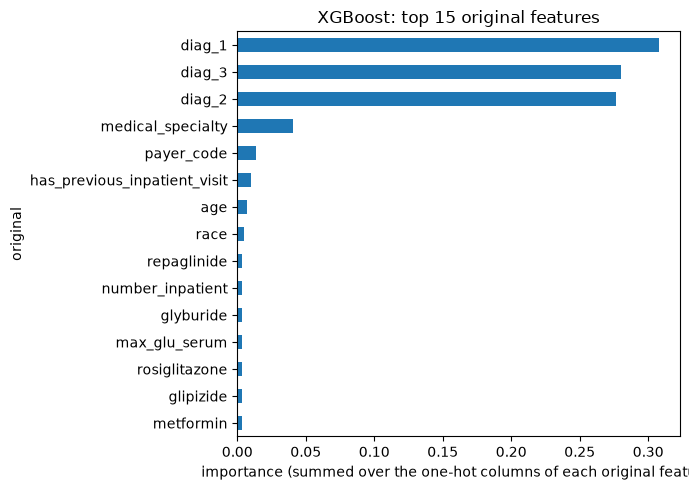

original
diag_1                          0.3078
diag_3                          0.2805
diag_2                          0.2765
medical_specialty               0.0409
payer_code                      0.0139
has_previous_inpatient_visit    0.0102
age                             0.0067
race                            0.0048
repaglinide                     0.0037
number_inpatient                0.0032
glyburide                       0.0032
max_glu_serum                   0.0032
rosiglitazone                   0.0031
glipizide                       0.0031
metformin                       0.0031
Name: value, dtype: float32

In [22]:
best = tune_res.best_estimator_
tbl = feature_importance_table(best, X_train.columns)
top = top_original_features(tbl, 15)
plot_top_features(top, f"{NAME}: top 15 original features", NAME)
top.round(4)